In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sh=pd.read_csv('/content/fiat500.csv')

In [ ]:
sh.head()

,ID,model,engine_power,age_in_days,km,previous_owners,lat,lon,price
0,1,lounge,51,882,25000,1,44.907242,8.611560,8900
1,2,pop,51,1186,32500,1,45.666359,12.241890,8800
2,3,sport,74,4658,142228,1,45.503300,11.417840,4200
3,4,lounge,51,2739,160000,1,40.633171,17.634609,6000
4,5,pop,73,3074,106880,1,41.903221,12.495650,5700


In [ ]:
sh=pd.read_csv('/content/fiat500.csv')
sh=pd.get_dummies(sh,columns=["model"],dtype=int)

In [ ]:
sh.tail(5)

,ID,model,engine_power,age_in_days,km,previous_owners,lat,lon,price
1515,1534,sport,51,3712,115280,1,45.069679,7.70492,5200
1516,1535,lounge,74,3835,112000,1,45.845692,8.66687,4600
1517,1536,pop,51,2223,60457,1,45.481541,9.41348,7500
1518,1537,lounge,51,2557,80750,1,45.000702,7.68227,5990
1519,1538,pop,51,1766,54276,1,40.323410,17.56827,7900


In [ ]:
sh.describe()

,ID,engine_power,age_in_days,km,previous_owners,lat,lon,price
count,1520.000000,1520.000000,1520.000000,1520.000000,1520.000000,1520.000000,1520.000000,1520.000000
mean,768.854605,51.915132,1657.190789,53602.474342,1.123684,43.539485,11.571552,8564.311842
std,443.599478,4.010360,1290.870689,40181.202940,0.415901,2.137960,2.332344,1942.771619
min,1.000000,51.000000,366.000000,1232.000000,1.000000,36.855839,7.245400,2500.000000
25%,383.750000,51.000000,670.000000,20000.000000,1.000000,41.794763,9.505090,7100.000000
50%,769.500000,51.000000,1066.000000,39162.000000,1.000000,44.394096,11.869260,9000.000000
75%,1151.250000,51.000000,2623.750000,80000.000000,1.000000,45.467960,12.786127,10000.000000
max,1538.000000,77.000000,4658.000000,235000.000000,4.000000,46.795612,18.365520,11100.000000


In [ ]:
sh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1520 entries, 0 to 1519
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               1520 non-null   int64  
 1   model            1520 non-null   object 
 2   engine_power     1520 non-null   int64  
 3   age_in_days      1520 non-null   int64  
 4   km               1520 non-null   int64  
 5   previous_owners  1520 non-null   int64  
 6   lat              1520 non-null   float64
 7   lon              1520 non-null   float64
 8   price            1520 non-null   int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 107.0+ KB


In [ ]:
sh.shape

(1520, 9)

In [ ]:
sh.dtypes

,0
ID,int64
model,object
engine_power,int64
age_in_days,int64
km,int64
previous_owners,int64
lat,float64
lon,float64
price,int64


In [ ]:
sh.sample(5)

,ID,model,engine_power,age_in_days,km,previous_owners,lat,lon,price
1046,1057,pop,51,670,45400,1,43.881889,10.80235,10500
1446,1463,pop,62,3470,90000,1,40.858898,14.35719,5199
1231,1246,lounge,51,1858,94752,1,45.536591,10.23204,7900
1227,1242,lounge,51,1917,53182,1,45.628132,9.04546,7900
746,756,lounge,51,2922,60600,1,44.504822,11.34518,9500


In [ ]:
len(sh)

1520

In [ ]:
import pandas as pd
sh=pd.read_csv('/content/fiat500.csv')
x=sh.drop(["ID","lat","lon","price"],axis=1)
y=sh["price"]

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
x

,model,engine_power,age_in_days,km,previous_owners
0,lounge,51,882,25000,1
1,pop,51,1186,32500,1
2,sport,74,4658,142228,1
3,lounge,51,2739,160000,1
4,pop,73,3074,106880,1
...,...,...,...,...,...
1515,sport,51,3712,115280,1
1516,lounge,74,3835,112000,1
1517,pop,51,2223,60457,1
1518,lounge,51,2557,80750,1


In [ ]:
y

,price
0,8900
1,8800
2,4200
3,6000
4,5700
...,...
1515,5200
1516,4600
1517,7500
1518,5990


In [ ]:
y.shape
y.head(10)

,price
0,8900
1,8800
2,4200
3,6000
4,5700
5,7900
6,10750
7,9190
8,5600
9,6000


In [ ]:
import pandas as pd
sh = pd.read_csv('/content/fiat500.csv')
sh.groupby(["model"]).count()

,ID,engine_power,age_in_days,km,previous_owners,lat,lon,price
model,,,,,,,,
lounge,1079,1079,1079,1079,1079,1079,1079,1079
pop,356,356,356,356,356,356,356,356
sport,85,85,85,85,85,85,85,85


<Axes: >

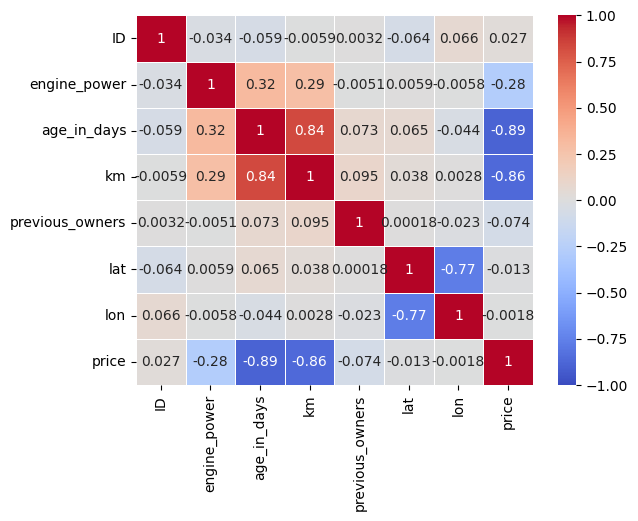

In [ ]:
cor_mat = sh.select_dtypes(include=np.number).corr()
sns.heatmap(cor_mat,vmax=1,vmin=-1,annot=True,linewidths=.5,cmap='coolwarm')

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import pandas as pd

# Create a copy of the 'sh' DataFrame and apply one-hot encoding to the 'model' column
sh_processed = sh.copy()
sh_processed = pd.get_dummies(sh_processed, columns=["model"], dtype=int)

# Define x (features) and y (target) from the processed DataFrame
x = sh_processed.drop(["ID", "lat", "lon", "price"], axis=1)
y = sh_processed["price"]

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Initialize and fit the Linear Regression model
reg = LinearRegression()
reg.fit(x_train, y_train)

LinearRegression()

In [ ]:
y_pred=reg.predict(x_test)
y_pred

array([ 9728.255012  ,  9937.34147124,  6585.64990063, 10306.14055706,
        9172.73691988,  6780.91274484,  9752.75679148, 10090.40103875,
        9698.55019574,  9515.94516832,  9688.9541188 ,  9297.19263495,
        9501.26990274,  8656.21143662, 10415.57423562,  7238.78142653,
        6962.17608107,  9882.99335312,  9768.96771772,  7723.10338523,
        4409.87351372,  5082.79914827,  9043.43065989, 10078.72064038,
        9327.0352938 ,  8394.87520238, 10034.16753536,  9917.23823403,
       10351.82747031,  8540.69218393, 10371.71011701, 10041.29068017,
        8840.1128311 ,  9616.04397145,  5461.33281849,  8321.26701718,
        9786.3686264 ,  9159.98809063,  8065.04871711, 10087.95925877,
        6966.96896066,  7037.47923706,  5720.94367441,  9419.28078387,
        5786.47870272,  8726.51966695,  9893.20488942, 10458.33988275,
        6384.43404077, 10325.75719079,  6401.73690518, 10083.2038545 ,
        9884.20626845,  5493.73776111, 10074.6761086 ,  9830.71473184,
      

In [ ]:
y_test

,price
461,9980
1314,9600
1472,6800
744,9890
247,10500
...,...
233,10900
481,10650
196,4900
1278,9700


In [ ]:
from sklearn.metrics import r2_score
r2_score(y_pred,y_test)

0.7868591706133933

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error as mape
mape_value=mape(y_test,y_pred)
mape_value

0.07953668269204285

In [ ]:
from sklearn.metrics import mean_squared_error         #calculating MSE
t=mean_squared_error(y_pred,y_test)
print(t**.5)                #squrae root

823.1496537039507


In [ ]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_pred,y_test)

620.1481483466196

In [ ]:
Results = pd.DataFrame()
Results["price"] = y_test
Results["predicted"] = y_pred
Results = Results.reset_index() # This will add the old index as a new column named 'index'
Results = Results.rename(columns={'index': 'Id'}) # Rename the 'index' column to 'Id'
Results.head(10)

,Id,price,predicted
0,461,9980,9728.255012
1,1314,9600,9937.341471
2,1472,6800,6585.649901
3,744,9890,10306.140557
4,247,10500,9172.736920
5,430,7950,6780.912745
6,939,9490,9752.756791
7,1490,9950,10090.401039
8,358,8579,9698.550196
9,427,9450,9515.945168


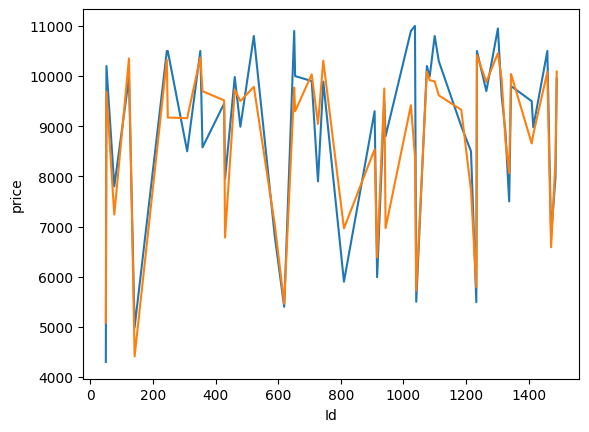

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.lineplot(x='Id',y='price',data=Results.head(50))
sns.lineplot(x='Id',y='predicted',data=Results.head(50))
plt.show()

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
alpha=[1e-15,1e-10,1e-8,1e-4,1e-3,1e-2,1,5,10,20,30]
ridge=Ridge()
param={'alpha':alpha}
ridge_reg=GridSearchCV(ridge,param)
ridge_reg.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.98547e-25): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.91137e-25): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.38717e-25): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.91016e-23): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.45973e-23): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/pytho

GridSearchCV(estimator=Ridge(),
             param_grid={'alpha': [1e-15, 1e-10, 1e-08, 0.0001, 0.001, 0.01, 1,
                                   5, 10, 20, 30]})